In [2]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
RUBLES = {
    'en-in': 0.7667,
    'en-pl': 20.1844,
    'en-tr': 1.61711,
}

In [4]:
df = pd.read_csv('../data/ps-store-games-details.csv')  # 9239

In [5]:
df['is_ru_voice'] = df['voice_langs'].str.contains('Russian', na=False)
df['is_ru_screen'] = df['screen_langs'].str.contains('Russian', na=False)
df['is_ru'] = df['is_ru_voice'] | df['is_ru_screen']
df['is_null'] = (
        df['voice_langs'].isnull()
        & df['screen_langs'].isnull()
        & df['offline_players'].isnull()
)

In [6]:
df.head()

,name,platforms,offset,product_id,country,base_price,discounted_price,genres,publisher,star_rating,age_rating,in_ps_plus,voice_langs,screen_langs,offline_players,is_ru_voice,is_ru_screen,is_ru,is_null
0,Battlefield™ 6,PS5,1872,UP0006-PPSA19534_00-SANTIAGOSTANDARD,en-in,"Rs 4,999","Rs 4,999",Shooter,NaN,4.09,PEGI_16,False,"Chinese, English, French (France), German, Ita...","Chinese (Simplified), English, French (France)...",NaN,False,False,False,False
1,CRYMELIGHT,PS5,0,EP2640-PPSA36937_00-PROJECTALICE0000,en-in,"Rs 1,664","Rs 1,497",Action,NaN,0.00,GENERIC_7,True,NaN,NaN,1 player,False,False,False,False
2,CRYMELIGHT Deluxe Edition,PS5,0,EP2640-PPSA36937_00-PJALICEDDX000000,en-in,"Rs 3,330","Rs 2,997",Action,NaN,0.00,GENERIC_7,True,NaN,NaN,1 player,False,False,False,False
3,STAR WARS: Galactic Racer™,PS5,0,UP8737-PPSA28416_00-SWGALACTICRACER1,en-in,"Rs 3,499","Rs 3,499",Driving/Racing,NaN,0.00,GENERIC_7,False,NaN,NaN,1 player,False,False,False,False
4,STAR WARS: Galactic Racer™ Deluxe Edition,PS5,0,UP8737-PPSA28416_00-SWGRDELUXEBUNDLE,en-in,"Rs 4,799","Rs 4,799","Action, Driving/Racing",NaN,0.00,GENERIC_7,False,NaN,NaN,1 player,False,False,False,False


## Количество игр с русской локализацией по странам

In [7]:
(df
    .groupby("country")
    .agg(
        total_count=("product_id", "count"),
        ru_count=("is_ru", lambda x: (x == True).sum()))
    .assign(
        ru_pct=lambda x: (x["ru_count"] / x["total_count"] * 100).round(2))
)

,total_count,ru_count,ru_pct
country,,,
en-in,9239,3824,41.39
en-pl,9239,3821,41.36
en-tr,9239,3796,41.09


## Стоимость игр в пересчете на рубли

In [13]:
def parse_price(row, col_name):
    value = row[col_name]

    if pd.isna(value):
        return pd.NA

    text = str(value).strip()

    if text == "Free":
        return -1
    if text == "Game Trial":
        return -2

    numeric = re.sub(r"[^\d,\.]", "", text)
    if not numeric:
        return pd.NA

    if row["country"] == "en-in":
        # 4,999 → запятая как разделитель тысяч
        numeric = numeric.replace(",", "")
    else:
        # 1.499,00 → точка как разделитель тысяч, запятая как дробная часть
        numeric = numeric.replace(".", "").replace(",", ".")

    return pd.to_numeric(numeric, errors='coerce')

df["base_price_num"] = df.apply(lambda row: parse_price(row, "base_price"), axis=1)
df["discounted_price_num"] = df.apply(lambda row: parse_price(row, "discounted_price"), axis=1)

In [39]:
def to_rub(price_num, country):
    if pd.isna(price_num) or price_num in (-1, -2):
        return price_num
    return int(round(price_num * RUBLES[country]))

df['rate_to_rub'] = df['country'].map(RUBLES)
df['base_price_rub'] = df.apply(lambda row: to_rub(row['base_price_num'], row['country']), axis=1)
df['discounted_price_rub'] = df.apply(lambda row: to_rub(row['discounted_price_num'], row['country']), axis=1)

<Axes: xlabel='base_price_rub', ylabel='Count'>

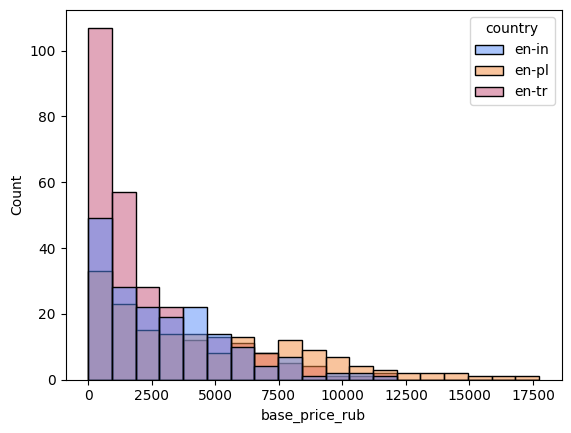

In [48]:
t = (df
    .groupby(["country","base_price_rub"])
    .agg(count=("product_id", "count"))
)
t
sns.histplot(data=t, x="base_price_rub", hue="country")